# **Project Name**    - DeepFER: Facial Emotion Recognition Using Deep Learning


##### **Project Type**    - Deep Learning / Computer Vision / Image Classification
##### **Contribution**    - Individual


# **Project Summary -**

DeepFER is a facial emotion recognition project that classifies human face images into seven emotion categories: angry, disgust, fear, happy, neutral, sad, and surprise. The project uses deep learning because emotion recognition from images depends on visual patterns such as eyes, mouth shape, eyebrows, facial muscle movement, and overall expression. These patterns are difficult to capture with manual rules, but Convolutional Neural Networks can learn them directly from image pixels.

The dataset is provided as a zipped image folder on Google Drive. It already contains separate training and validation folders, with each emotion stored in its own class folder. The notebook mounts Google Drive, extracts the zip file into the local Colab runtime, and trains from /content. This keeps the workflow faster than reading thousands of small images directly from Google Drive. The dataset is then inspected for folder structure, class counts, unsupported files, corrupt images, duplicate image hashes, image size, file size, and sample brightness patterns. This satisfies the data integrity and cleaning requirement without changing the original dataset unnecessarily.

The preprocessing pipeline resizes all images to a consistent shape, converts images into tensors, scales pixel values, and applies data augmentation. Augmentation creates small realistic variations such as horizontal flips, slight rotations, zoom, and contrast changes. This helps the model generalize better because real faces can appear with small position, lighting, or angle differences. Since the data is image-based, traditional tabular feature engineering is not forced. Instead, the notebook explains image-specific feature preparation and uses CNN layers to learn visual features automatically.

Three modeling stages are included. The first model is a simple baseline CNN to create a clear starting point. The second model is a reference-style FER CNN with batch normalization, dropout, image augmentation, early stopping, and learning-rate reduction. It is the selected final model because it gives the best balanced result on this dataset. The third model uses EfficientNetB0 transfer learning as a practical comparison. Transfer learning is included because it can reuse visual patterns learned from a large image dataset, but its lower validation result here shows that a custom CNN can be more suitable for small 48x48 grayscale face images.

The models are evaluated using accuracy, precision, recall, F1-score, classification report, and confusion matrix. Macro F1-score is emphasized because the dataset is imbalanced, especially for the disgust class. In the final run, the reference-style FER CNN achieved 0.654 validation accuracy and 0.616 macro F1-score on the leakage-safe split, and 0.666 accuracy with 0.641 macro F1-score on the official validation split. The notebook also includes a simple explainability step using occlusion sensitivity, which shows which image regions affect the final prediction. The best model is saved to Google Drive, loaded again, and tested on unseen validation data as a sanity check. This makes the notebook complete, practical, and aligned with the AlmaBetter capstone requirements.


# **GitHub Link -**

GitHub Repository Link: https://github.com/I-AM-PRASHANT-VERMA/Almabetter---DeepFER-Facial-Emotion-Recognition-Using-Deep-Learning


# **Problem Statement**


The objective of this project is to build a deep learning model that can classify facial images into seven emotion categories: angry, disgust, fear, happy, neutral, sad, and surprise. The model should learn useful visual patterns from face images, perform well on unseen data, and provide clear evaluation results using classification metrics.

This problem is important because facial emotion recognition can support human-computer interaction, customer experience analysis, mental health monitoring, learning platforms, and smart assistance systems. The project focuses on a notebook-level solution that is accurate, explainable, and executable in one run on Google Colab.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Code Cell 00: Import Libraries
# Import core libraries used across the notebook.
import os
import zipfile
import random
import hashlib
from pathlib import Path
from collections import Counter
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from scipy import stats

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Keep image loading stable even if a file has minor truncation.
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Keep results more reproducible across runs.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Use mixed precision on GPU when available to make training faster.
try:
    if tf.config.list_physical_devices('GPU'):
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision enabled for GPU training')
except Exception as mixed_precision_error:
    print('Mixed precision was not enabled:', mixed_precision_error)

# Use a clean plotting style for all charts.
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries imported successfully')


Mixed precision enabled for GPU training
Libraries imported successfully


### Dataset Loading

In [ ]:
# Code Cell 01: Mount Google Drive And Check Dataset Zip
# Mount Google Drive so the dataset zip can be read from the project folder.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Google Drive mounting is available only inside Google Colab.')

PROJECT_DRIVE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/# specialization projects/5th project DeepFER Facial Emotion Recognition Using Deep Learning')
DATASET_ZIP_PATH = PROJECT_DRIVE_DIR / 'dataset' / 'Face Emotion Recognition Dataset.zip'
LOCAL_EXTRACT_DIR = Path('/content/deepfer_dataset')
OUTPUT_DIR = PROJECT_DRIVE_DIR / 'outputs'

# Keep all generated files in one Drive output folder.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_ZIP_PATH.exists():
    raise FileNotFoundError(f'Dataset zip not found: {DATASET_ZIP_PATH}')

print('Dataset zip found:', DATASET_ZIP_PATH)
print('Output folder:', OUTPUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset zip found: /content/drive/MyDrive/Colab Notebooks/# specialization projects/5th project DeepFER Facial Emotion Recognition Using Deep Learning/dataset/Face Emotion Recognition Dataset.zip
Output folder: /content/drive/MyDrive/Colab Notebooks/# specialization projects/5th project DeepFER Facial Emotion Recognition Using Deep Learning/outputs


In [ ]:
# Code Cell 02: Extract Dataset And Set Folder Paths
# Extract the zip only when the local runtime folder is not ready.
train_check_dir = LOCAL_EXTRACT_DIR / 'images' / 'images' / 'train'
validation_check_dir = LOCAL_EXTRACT_DIR / 'images' / 'images' / 'validation'

if not train_check_dir.exists() or not validation_check_dir.exists():
    LOCAL_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(DATASET_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_EXTRACT_DIR)
    print('Dataset extracted successfully')
else:
    print('Dataset already extracted in the current Colab runtime')

TRAIN_DIR = LOCAL_EXTRACT_DIR / 'images' / 'images' / 'train'
VALIDATION_DIR = LOCAL_EXTRACT_DIR / 'images' / 'images' / 'validation'
CLASS_NAMES = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])

print('Train directory:', TRAIN_DIR)
print('Validation directory:', VALIDATION_DIR)
print('Classes:', CLASS_NAMES)


Dataset already extracted in the current Colab runtime
Train directory: /content/deepfer_dataset/images/images/train
Validation directory: /content/deepfer_dataset/images/images/validation
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### Dataset First View

In [ ]:
# Code Cell 03: Create Image Metadata Table
# Build a clean metadata table from the image folders.
def build_image_metadata(split_name, split_dir):
    rows = []
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            for image_path in sorted(class_dir.glob('*')):
                if image_path.is_file():
                    rows.append({
                        'split': split_name,
                        'label': class_dir.name,
                        'file_name': image_path.name,
                        'file_path': str(image_path),
                        'extension': image_path.suffix.lower(),
                        'file_size_kb': image_path.stat().st_size / 1024
                    })
    return rows

metadata_rows = []
metadata_rows.extend(build_image_metadata('train', TRAIN_DIR))
metadata_rows.extend(build_image_metadata('validation', VALIDATION_DIR))
metadata_df = pd.DataFrame(metadata_rows)

print('Metadata table created successfully')
display(metadata_df.head())


Metadata table created successfully


,split,label,file_name,file_path,extension,file_size_kb
0,train,angry,0.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.485352
1,train,angry,1.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.650391
2,train,angry,10.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.653320
3,train,angry,10002.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.610352
4,train,angry,10016.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.685547


### Dataset Rows & Columns count

In [ ]:
# Code Cell 04: Count Images By Split And Emotion
# Count images by split and emotion class.
class_count_table = (
    metadata_df
    .groupby(['split', 'label'])
    .size()
    .reset_index(name='image_count')
)

split_count_table = (
    metadata_df
    .groupby('split')
    .size()
    .reset_index(name='total_images')
)

print('Image count by split')
display(split_count_table)

print('Image count by split and class')
display(class_count_table)


Image count by split


,split,total_images
0,train,28821
1,validation,7066


Image count by split and class


,split,label,image_count
0,train,angry,3993
1,train,disgust,436
2,train,fear,4103
3,train,happy,7164
4,train,neutral,4982
5,train,sad,4938
6,train,surprise,3205
7,validation,angry,960
8,validation,disgust,111
9,validation,fear,1018


### Dataset Information

In [ ]:
# Code Cell 05: Review Metadata Details
# Review metadata structure and basic file details.
print('Metadata shape:', metadata_df.shape)
print()
print('Metadata info:')
metadata_df.info()

print()
print('File size summary in KB:')
display(metadata_df['file_size_kb'].describe().to_frame().T)


Metadata shape: (35887, 6)

Metadata info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   split         35887 non-null  object 
 1   label         35887 non-null  object 
 2   file_name     35887 non-null  object 
 3   file_path     35887 non-null  object 
 4   extension     35887 non-null  object 
 5   file_size_kb  35887 non-null  float64
dtypes: float64(1), object(5)
memory usage: 1.6+ MB

File size summary in KB:


,count,mean,std,min,25%,50%,75%,max
file_size_kb,35887.0,1.537764,0.158123,0.350586,1.438477,1.541016,1.639648,2.424805


#### Duplicate Values

In [ ]:
# Code Cell 06: Check Exact Duplicate Images
# Use file hashes to identify exact duplicate image files.
def get_file_hash(file_path):
    hash_obj = hashlib.md5()
    with open(file_path, 'rb') as file_obj:
        for chunk in iter(lambda: file_obj.read(8192), b''):
            hash_obj.update(chunk)
    return hash_obj.hexdigest()

metadata_df['file_hash'] = metadata_df['file_path'].apply(get_file_hash)
duplicate_image_count = metadata_df.duplicated(subset=['file_hash']).sum()
duplicate_name_count = metadata_df.duplicated(subset=['split', 'label', 'file_name']).sum()

print('Exact duplicate image count:', duplicate_image_count)
print('Duplicate file name count inside same split and class:', duplicate_name_count)


Exact duplicate image count: 1853
Duplicate file name count inside same split and class: 0


#### Missing Values/Null Values

In [ ]:
# Code Cell 07: Check Invalid Image Files
# Check unsupported extensions and unreadable image files.
supported_extensions = {'.jpg', '.jpeg', '.png'}
unsupported_files = metadata_df[~metadata_df['extension'].isin(supported_extensions)]

def image_is_readable(file_path):
    try:
        with Image.open(file_path) as img:
            img.verify()
        return True
    except Exception:
        return False

metadata_df['is_readable'] = metadata_df['file_path'].apply(image_is_readable)
invalid_image_count = int((~metadata_df['is_readable']).sum())

print('Unsupported file count:', len(unsupported_files))
print('Unreadable image count:', invalid_image_count)


Unsupported file count: 0
Unreadable image count: 0


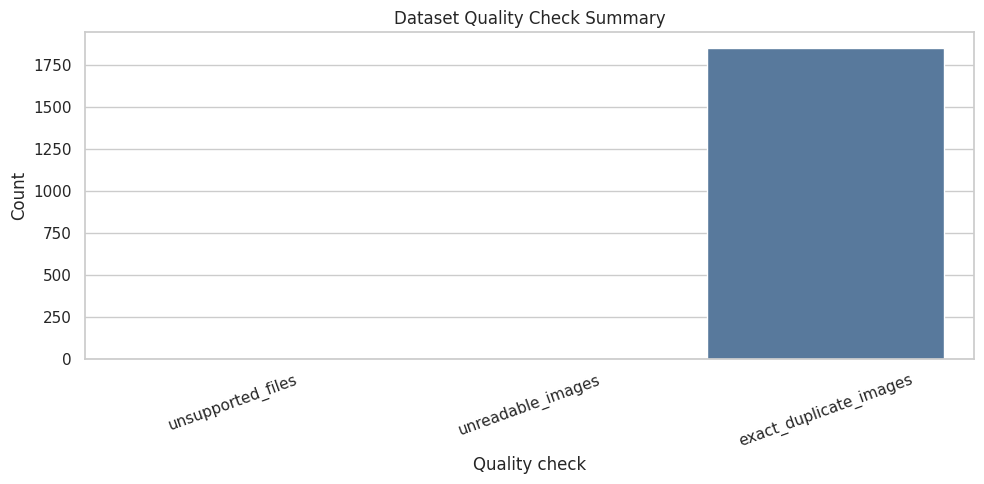

,check,count
0,unsupported_files,0
1,unreadable_images,0
2,exact_duplicate_images,1853


In [ ]:
# Code Cell 08: Visualize Data Quality Summary
# Visualize basic data quality checks.
quality_summary = pd.DataFrame({
    'check': ['unsupported_files', 'unreadable_images', 'exact_duplicate_images'],
    'count': [len(unsupported_files), invalid_image_count, int(duplicate_image_count)]
})

sns.barplot(data=quality_summary, x='check', y='count', color='#4C78A8')
plt.title('Dataset Quality Check Summary')
plt.xlabel('Quality check')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(quality_summary)


### What did you know about your dataset?

The dataset is an image-folder dataset with two main splits: training and validation. The output shows 28,821 training images and 7,066 validation images. Each emotion class is stored as a separate folder, so the folder name becomes the target label.

The class distribution is not balanced. Happy has the largest share, while disgust has the smallest share. This matters because a model can get reasonable accuracy by focusing on common classes, but it may still fail on rare classes. For this reason, macro F1-score, class-wise recall, prediction distribution, and confusion matrix are more useful than accuracy alone. The zip file is loaded from Google Drive and extracted into /content so Colab can read the images faster during training.

## ***2. Understanding Your Variables***

In [ ]:
# Code Cell 09: Show Metadata Columns
# Show the available metadata columns.
print('Metadata columns:')
print(metadata_df.columns.tolist())


Metadata columns:
['split', 'label', 'file_name', 'file_path', 'extension', 'file_size_kb', 'file_hash', 'is_readable']


In [ ]:
# Code Cell 10: Summarize Metadata And Label Share
# Summarize numeric fields available before model training.
display(metadata_df[['file_size_kb']].describe())

print('Label distribution percentage:')
label_percent = metadata_df['label'].value_counts(normalize=True).mul(100).round(2)
display(label_percent.to_frame(name='percentage'))


,file_size_kb
count,35887.000000
mean,1.537764
std,0.158123
min,0.350586
25%,1.438477
50%,1.541016
75%,1.639648
max,2.424805


Label distribution percentage:


,percentage
label,
happy,25.05
neutral,17.27
sad,16.93
fear,14.27
angry,13.80
surprise,11.15
disgust,1.52


### Variables Description

The project does not contain tabular business variables. It contains image files and labels. The useful variables are created from folder structure and image metadata:

- split: identifies whether an image belongs to train or validation data.
- label: target emotion class taken from the folder name.
- file_path: exact image location used for loading.
- file_name: image file name.
- extension: file type such as .jpg.
- file_size_kb: image file size, useful for checking unusual files.
- file_hash: hash used to detect exact duplicate images.
- is_readable: tells whether the file can be opened as an image.

Later, the notebook also creates image profile features such as width, height, mean pixel value, and pixel standard deviation for EDA and hypothesis testing. These are not final model inputs; the CNN learns visual features directly from image tensors.


### Check Unique Values for each variable.

In [ ]:
# Code Cell 11: Check Unique Metadata Values
# Check unique values for key metadata columns.
for column in ['split', 'label', 'extension', 'is_readable']:
    print(f'Unique values in {column}:')
    print(metadata_df[column].unique())
    print()


Unique values in split:
['train' 'validation']

Unique values in label:
['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']

Unique values in extension:
['.jpg']

Unique values in is_readable:
[ True]



## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Code Cell 12: Prepare Wrangling Objects And Image Profiles
# Keep image size aligned with the FER-style face images in this dataset.
IMG_SIZE = (48, 48)
TRANSFER_IMG_SIZE = (128, 128)
BATCH_SIZE = 128
BASELINE_EPOCHS = 8
TUNED_EPOCHS = 50
TRANSFER_HEAD_EPOCHS = 6
TRANSFER_FINE_TUNE_EPOCHS = 4
MAX_PROFILE_PER_CLASS = 80

# Create stable label-to-number mappings for all model outputs.
class_to_index = {class_name: index for index, class_name in enumerate(CLASS_NAMES)}
index_to_class = {index: class_name for class_name, index in class_to_index.items()}

# Compute class weights from the training split because the emotion classes are imbalanced.
train_labels_as_int = metadata_df.loc[metadata_df['split'] == 'train', 'label'].map(class_to_index).to_numpy()
raw_class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=train_labels_as_int
)
raw_class_weight_dict = {index: float(weight) for index, weight in enumerate(raw_class_weight_values)}

# Use moderated class weights so the small disgust class does not dominate training.
class_weight_dict = {
    index: float(min(np.sqrt(weight), 3.0))
    for index, weight in raw_class_weight_dict.items()
}

# Profile a fixed sample so EDA stays fast and repeatable.
profile_samples = []
for (_, _), group_df in metadata_df.groupby(['split', 'label']):
    sample_size = min(MAX_PROFILE_PER_CLASS, len(group_df))
    profile_samples.append(group_df.sample(sample_size, random_state=SEED))

profile_sample_df = pd.concat(profile_samples, ignore_index=True)

def read_image_profile(file_path):
    # Read each sampled image in grayscale and calculate simple brightness features.
    with Image.open(file_path).convert('L') as img:
        width, height = img.size
        resized_img = img.resize(IMG_SIZE)
        arr = np.asarray(resized_img, dtype=np.float32)
    return {
        'width': width,
        'height': height,
        'mean_pixel': float(arr.mean()),
        'std_pixel': float(arr.std())
    }

# Build a sampled image-profile table for EDA and hypothesis testing.
profile_records = []
for row in profile_sample_df.itertuples(index=False):
    profile = read_image_profile(row.file_path)
    profile.update({
        'split': row.split,
        'label': row.label,
        'file_path': row.file_path,
        'file_size_kb': row.file_size_kb
    })
    profile_records.append(profile)

image_profile_df = pd.DataFrame(profile_records)

# Keep augmentation realistic because strong distortions can change facial expression meaning.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal', seed=SEED),
    layers.RandomRotation(0.06, seed=SEED),
    layers.RandomZoom(0.08, seed=SEED),
    layers.RandomTranslation(0.05, 0.05, seed=SEED),
    layers.RandomContrast(0.08, seed=SEED)
], name='data_augmentation')

print('Wrangling objects created successfully')
print('Class mapping:', class_to_index)
print('Raw class weights:', raw_class_weight_dict)
print('Moderated class weights:', class_weight_dict)
display(image_profile_df.head())


Wrangling objects created successfully
Class mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Raw class weights: {0: 1.031125898894494, 1: 9.443315858453474, 2: 1.0034817729187702, 3: 0.5747188322565207, 4: 0.8264322991340254, 5: 0.8337962159347335, 6: 1.2846445286382884}
Moderated class weights: {0: 1.0154436955806532, 1: 3.0, 2: 1.001739373748866, 3: 0.7581021252156734, 4: 0.9090832190366432, 5: 0.9131244252207547, 6: 1.1334216023344041}


,width,height,mean_pixel,std_pixel,split,label,file_path,file_size_kb
0,48,48,107.316406,40.739243,train,angry,/content/deepfer_dataset/images/images/train/a...,1.415039
1,48,48,130.469177,54.184982,train,angry,/content/deepfer_dataset/images/images/train/a...,1.526367
2,48,48,81.891060,66.492241,train,angry,/content/deepfer_dataset/images/images/train/a...,1.444336
3,48,48,144.276917,51.366524,train,angry,/content/deepfer_dataset/images/images/train/a...,1.630859
4,48,48,95.356339,41.230492,train,angry,/content/deepfer_dataset/images/images/train/a...,1.338867


### What all manipulations have you done and insights you found?

The raw image folders were converted into a metadata table for analysis. The main manipulations were class counting, file quality checks, exact duplicate checking, class-weight calculation, and image profile sampling.

The output confirms that this is an imbalanced image classification problem. Disgust has far fewer images than the other emotions, while happy has the largest count. This imbalance directly affects model training, so the notebook uses moderated class weights and macro F1-score. The image profiles also confirm that the images are already small 48x48 face images, which makes a FER-style CNN a suitable model choice.